<a href="https://colab.research.google.com/github/ThanhTruc297PRJ/TH_DLN/blob/main/Buoi2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#BÀI 1

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Load Data từ GitHub của Thầy
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/23_HOMES.csv"
df = pd.read_csv(url)

# --- PHẦN 1: HEAD ---
print("\n" + "="*20 + " 1. DF HEAD " + "="*20)
print(df.head())
print("="*52)

# --- PHẦN 2: INFO ---
print("\n" + "="*20 + " 2. DF INFO " + "="*20)
print(df.info())
print("="*52)

# --- PHẦN 3: KIỂM TRA NULL ---
print("\n" + "="*20 + " 3. NULL SUM " + "="*20)
print(df.isnull().sum())
print("="*52)

# Làm sạch dữ liệu
df = df.dropna()

# --- PHẦN 4: CORRELATION ---
print("\n" + "="*15 + " 4. SELLING PRICE CORR " + "="*15)
corr = df.corr(numeric_only=True)
print(corr["Selling_Price"].sort_values(ascending=False))
print("="*52)

# Target
y = df["Selling_Price"]

# Input
X = df[["List_Price", "Area", "Taxes", "Rooms", "Bedrooms", "Baths_full"]]

# DataScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Chia Dữ Liệu
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Giá nhà
y_pred = model.predict(X_test)

# --- PHẦN 5: Y_PRED ---
print("\n" + "="*19 + " 5. Y PREDICT " + "="*19)
print(y_pred)
print("="*52)

# Sai số
error = y_pred - y_test

# --- PHẦN 6: ERROR ---
print("\n" + "="*21 + " 6. ERROR " + "="*21)
print(error)
print("="*52)

# Đánh giá
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# --- PHẦN 7: METRICS & PREDICT NEW ---
print("\n" + "="*16 + " 7. EVALUATE & TEST " + "="*16)
print("MAE =", mae)
print("R2 =", r2)
print("-" * 52)

# Thử giá nhà mới
new_house = pd.DataFrame(
    [[450000, 2500, 6000, 8, 4, 2]],
    columns=["List_Price", "Area", "Taxes", "Rooms", "Bedrooms", "Baths_full"],
)
new_house_scaled = scaler.transform(new_house)
predicted_price = model.predict(new_house_scaled)

print("Predicted Price =", predicted_price[0])
print("="*52 + "\n")


==================== 1. DF HEAD ====================
   Selling_Price  List_Price  Area  Acres  Age  Taxes  Rooms  Bedrooms  \
0         400000      414000  2704   2.27   27   4920      9         3   
1         370000      379000  2096   0.75   21   4113      8         4   
2         382500      389900  2737   1.00   36   6072      9         4   
3         300000      299900  1800   0.43   34   4024      8         4   
4         305000      319900  1066   3.60   69   3562      6         3   

   Baths_full  
0           3  
1           2  
2           2  
3           2  
4           2  

==================== 2. DF INFO ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Selling_Price  40 non-null     int64  
 1   List_Price     40 non-null     int64  
 2   Area           40 non-null     int64  
 3   Acres          40 non-nu

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]


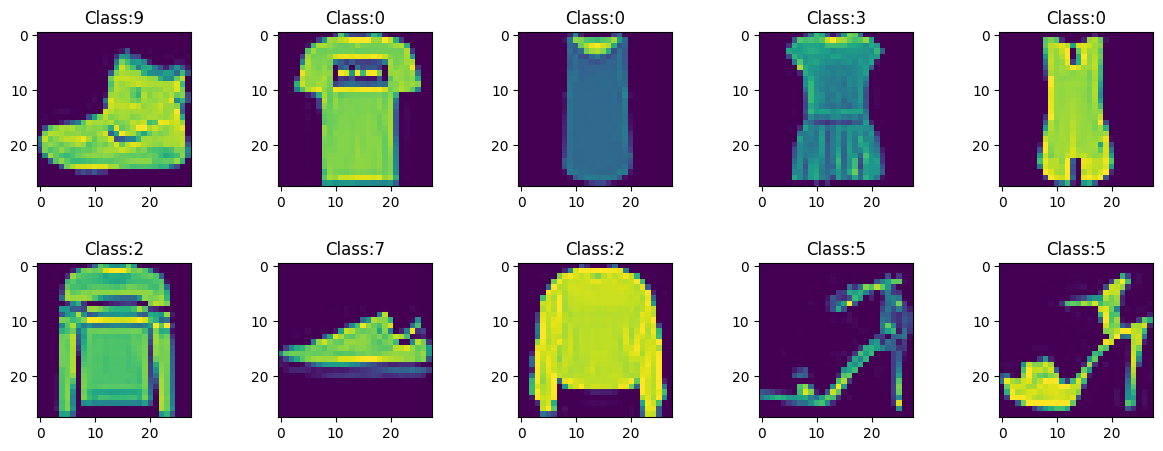

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [2]:
#BÀI 2

##Cài Đặt Thư Viện
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.preprocessing import image
from keras.layers import Dropout


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

##Tải bộ MNist fashion dataset
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print (X_train.shape, y_train.shape, X_test.shape, y_test.shape)

##Xử lý dữ liệu
#reshapre from 3-D to 2D
X_train = X_train.reshape (60000, 784)
X_test = X_test.reshape (10000, 784)
#feature scaling
minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform (X_test)

print ('Number of classes: ', len(np.unique(y_train)))
print ('Classes: ',np.unique(y_train))

##Trực quan hóa dữ liệu
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()
##Xây dựng mô hình học
#initial ANN model
fashion_model = Sequential()

#add first hidden layer
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

#add output layer
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

#compile neural network
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#model summary
fashion_model.summary()



Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8183 - loss: 0.5103 - val_accuracy: 0.8527 - val_loss: 0.4203
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8642 - loss: 0.3710 - val_accuracy: 0.8600 - val_loss: 0.3766
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8772 - loss: 0.3313 - val_accuracy: 0.8722 - val_loss: 0.3509
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8859 - loss: 0.3066 - val_accuracy: 0.8847 - val_loss: 0.3324
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8931 - loss: 0.2873 - val_accuracy: 0.8645 - val_loss: 0.3846
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8983 - loss: 0.2737 - val_accuracy: 0.8842 - val_loss: 0.3217
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.9032 - loss: 0.2589 - val_accuracy: 0.8812 - val_loss: 0.3386
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9073 - loss: 0

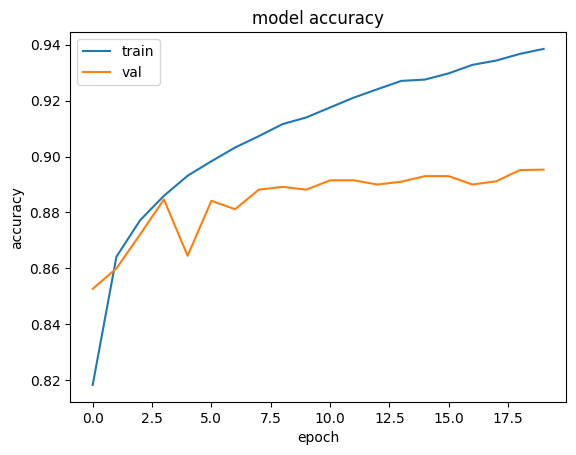

In [3]:
##Train Model
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20,verbose =1)

##Đánh giá
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()


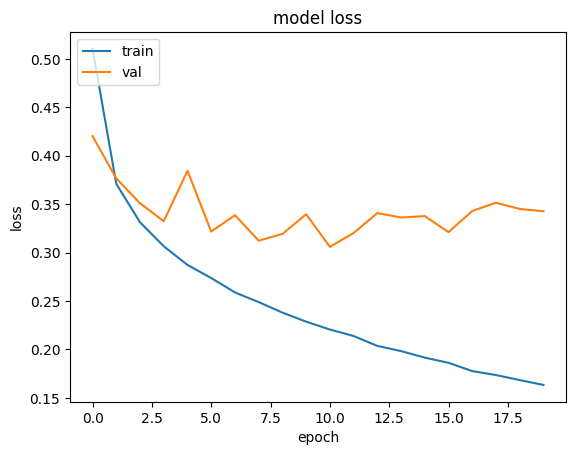

In [4]:
plt.plot (model_fit.history['loss'])
plt.plot (model_fit.history['val_loss'])
plt.title ('model loss')
plt.ylabel ('loss')
plt.xlabel ('epoch')
plt.legend (['train', 'val'], loc='upper left')

In [5]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [6]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Đọc dữ liệu
mnist_train_path = '/content/sample_data/mnist_train_small.csv'
mnist_test_path = '/content/sample_data/mnist_test.csv'
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)

# Tách dữ liệu và chuẩn hóa
X_train = mnist_train.iloc[:, 1:].values / 255.0
X_test = mnist_test.iloc[:, 1:].values / 255.0
y_train = mnist_train.iloc[:, 0].values
y_test = mnist_test.iloc[:, 0].values

# Xây dựng mô hình
model = Sequential([
    Dense(256, input_shape=(784,), activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Huấn luyện
model.fit(X_train, y_train, epochs=30, verbose=1)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9005 - loss: 0.3536
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9550 - loss: 0.1543
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9702 - loss: 0.1036
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9791 - loss: 0.0715
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9858 - loss: 0.0516
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9905 - loss: 0.0350
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9927 - loss: 0.0278
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9952 - loss: 0.0189
Epoch 9/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9972 - loss: 0.0126
Epoch 10/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9967 - loss: 0.0133
Epoch 11/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9979 - loss: 0.0092
Epoch 12/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

In [7]:
# Dự đoán và đánh giá
y_pred = model.predict(X_test)
print(np.argmax(y_pred[0]), y_test[0])
print(np.argmax(y_pred[10]), y_test[10])

img_size = (28, 28)
img = tf.keras.preprocessing.image.load_img(
    '/content/sample_data/dress.jpg', color_mode='grayscale', target_size=img_size)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array, (784))
img_array = tf.expand_dims(img, 0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)
#print(img_array.reshape(None, 784))

img_predict = model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
2 2
6 6


FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/dress.jpg'